In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from util.static import PATH_OUTPUT, PATH_LABELING

# Data Visualization

This notebook contains the code to visualize the distribution of the labeled data (both the automatic and manual) on file (i.e., subflow) level.

## Data Preparation

Firstly, load the individual data sets and bring them into a shared format. There are three data sources to bring together:

1. The manually labeled data on sentence-level
2. The manually labeled data on subflow-level
3. The automatically labeled data on subflow-level

### Manually Labeled Data

The manually labeled data needs to be brought into a common format, i.e., the sentence-level labels need to be aggregated per subflow.

In [3]:
# determine the file name of the manually labeled data set
data_manual_filename: str = os.path.join(PATH_LABELING, 'rq4tlr-manual-variables.xlsx')

# load the manually labeled data sets on both the requirements (req) and sentences (sen) level
dfm_req = pd.read_excel(data_manual_filename, sheet_name='Requirements R2')
dfm_sen = pd.read_excel(data_manual_filename, sheet_name='Sentences R2')

# drop the "Comment" column from both data frames
dfm_req.drop(columns=['Comment', 'Inconsistent Level of Abstraction', 'Contains clarification'], inplace=True)
dfm_sen.drop(columns=['Comment'], inplace=True)

In [4]:
# specify the sentence-level variables that need to be aggregated
manual_sentence_variables: list[str] = [
    "Coordination Ambiguity", 
    "Contains UI Design Details", 
    "Contains Alternative", 
    "Inconsistent Level of Abstraction", 
    "Contains Clarification"]

# aggregate the rows of dfm_sen per Dataset and File column
dfm_sen_aggregated = dfm_sen.groupby(['Dataset', 'File'])[manual_sentence_variables].mean()
# reset the index of the aggregated data frame
dfm_sen_aggregated = dfm_sen_aggregated.reset_index()

In [9]:
# join the dfm_req and dfm_sen_aggregated data frames on the Dataset and File columns
dfm = dfm_req.merge(dfm_sen_aggregated, on=['Dataset', 'File'], how='left')

# make all strings in the dataset column lowercase
dfm['Dataset'] = dfm['Dataset'].str.lower()

In [6]:
# define the requirements-level variables that correspond to the column namens
manual_requirements_variables: list[str] = [
    "Functional Duplication", 
    "Use Case Naming Problems", 
    "Inappropriate Scope",
    "Incoherent Text Order",
    "Inputs or Outputs not quantified",
    "Contains NFRs",
    "Contains Actor-Actor Interaction",
    "Contains justifications"]

### Automatically labeled Data

Next, load the automatically labeled data (which is already harmonized on a subflow-level). This data set can be merged with the harmonized manually labeled data set.

In [10]:
# determine the file name of the automatically labeled data set
data_automatic_filename: str = os.path.join(PATH_OUTPUT, 'rq4tlr-automatic-aggregated.csv')

# load the data set
dfa: pd.DataFrame = pd.read_csv(data_automatic_filename)

# rename the dataset and file columns to match the manual data set
dfa.rename(columns={'dataset': 'Dataset', 'file': 'File'}, inplace=True)

In [11]:
# merge the manual and automatic data sets on the Dataset and File columns
df = dfm.merge(dfa, on=['Dataset', 'File'], how='left')

In [12]:
# specify the automatically labeled variables and categorize them by their respective type
automatic_variables: dict[str, list[str]] = {
    "boolean": ["happy_ucs", "meaningless_uc", "tangled_requirements", "scattered_requirements", "nfrs", "anaphora", "optional", "starts_without_nounphrase", "incomplete_comparisons", "passive", "negation"],
    "count": ["large_ucs", "meaningless_actor", "max_requirements_length", "max_sentence_complexity"],
    "ratio": ["coherence"]
}

In [13]:
# join all variable names together in a dictionary that associates each variable with its type
variables: dict[str, list[str]] = automatic_variables.copy()
variables["boolean"] += manual_requirements_variables
variables["ratio"] += manual_sentence_variables

## Visualization

Next, visualize the distribution of each variable.

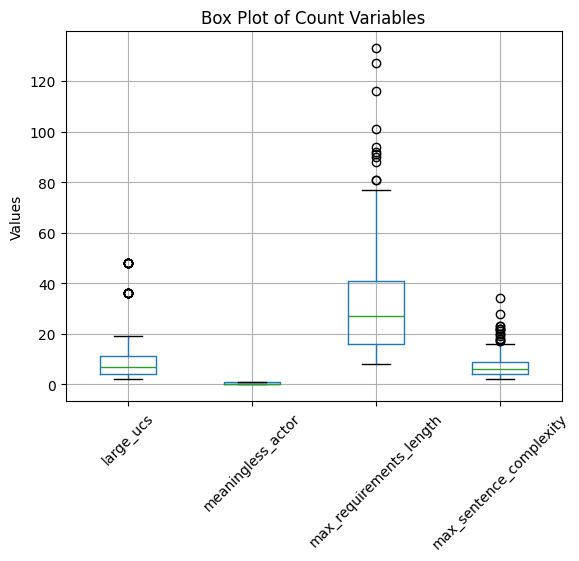

In [14]:
# Generate a box plot for each variable in the "count" category
df[variables["count"]].boxplot()

# Set the title and labels
plt.title('Box Plot of Count Variables')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

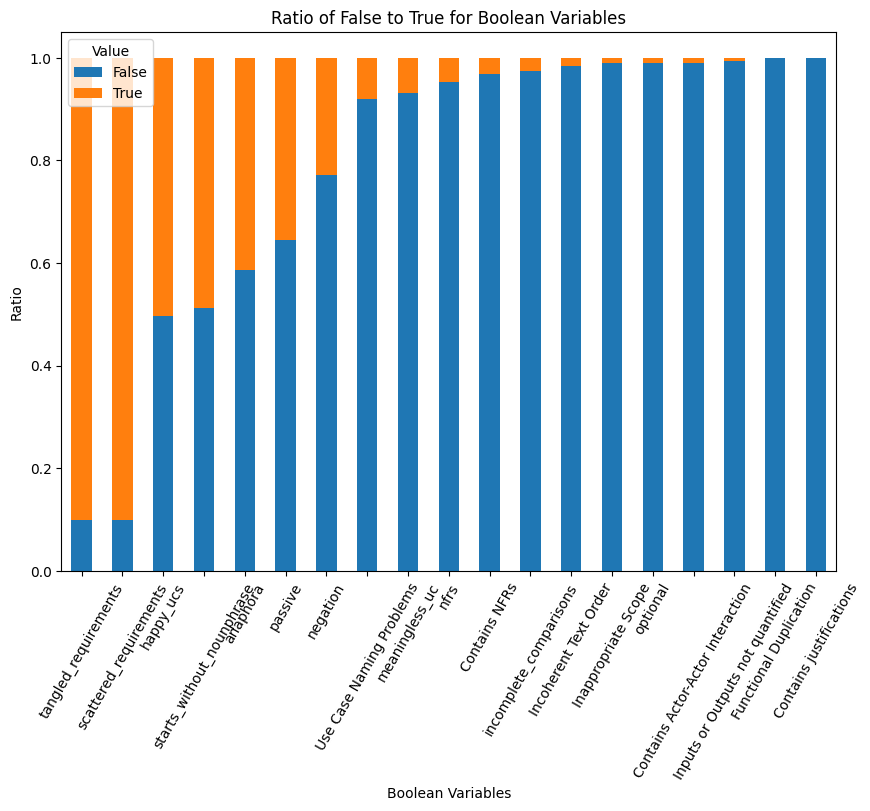

In [21]:
# Calculate the ratio of True to False for each boolean variable
boolean_ratios = df[variables["boolean"]].apply(lambda x: x.value_counts(normalize=True)).T
# order the variables by the count of True values
boolean_ratios = boolean_ratios.sort_values(True, ascending=False)
boolean_ratios.columns = ['False', 'True']

# Plot the stacked bar chart
boolean_ratios.plot(kind='bar', stacked=True, figsize=(10, 7))

# Set the title and labels
plt.title('Ratio of False to True for Boolean Variables')
plt.xlabel('Boolean Variables')
plt.ylabel('Ratio')
plt.xticks(rotation=60)
plt.legend(title='Value')
plt.show()

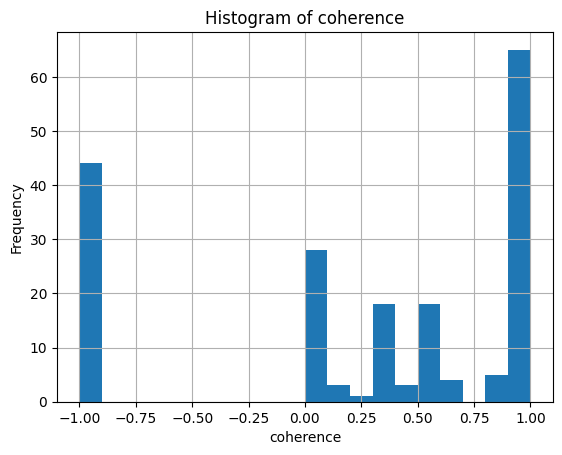

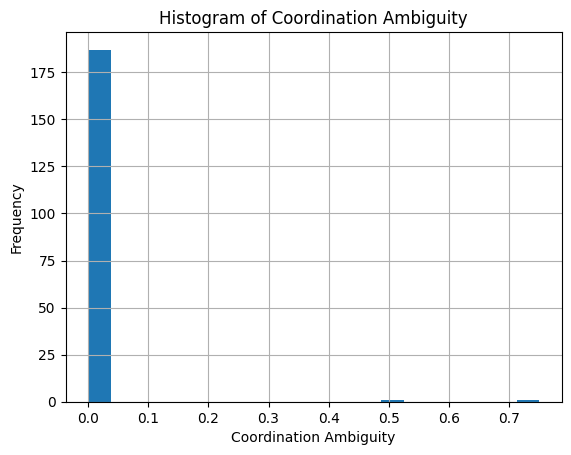

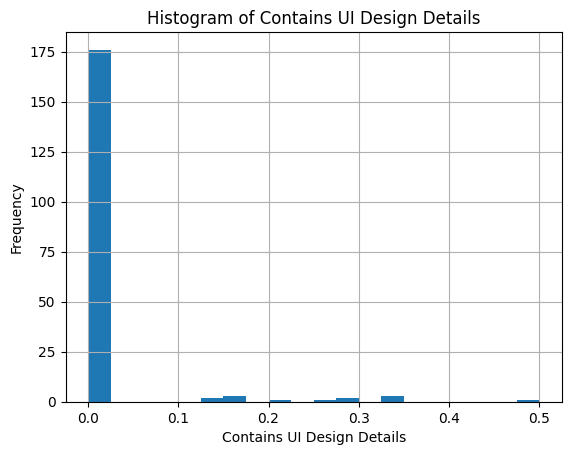

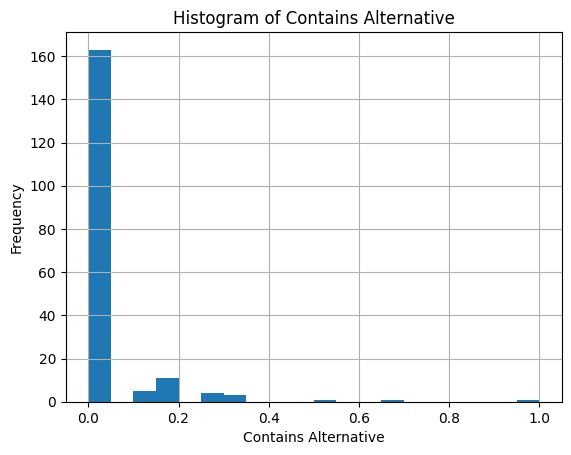

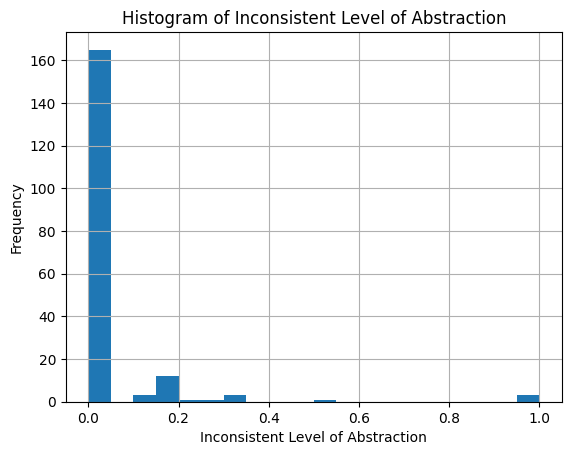

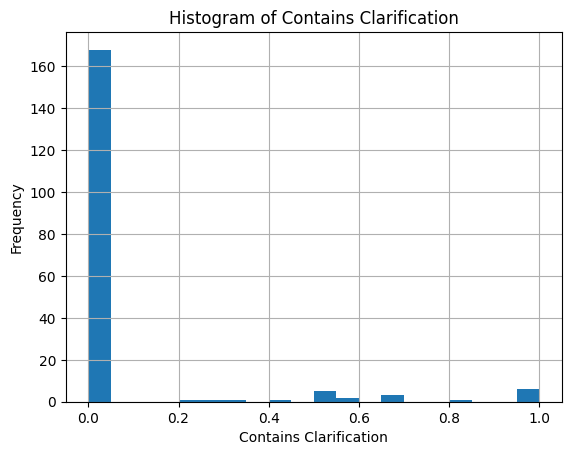

In [19]:
# Generate a histogram for each variable in the "ratio" category
for variable in variables["ratio"]:
    df[variable].hist(bins=20)
    plt.title(f'Histogram of {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.show()